## Comparing Efficient Multi-Head Attnetion Implementations.....

 * This code compares the different ways to implement casual multi-head attention used in decoder-style LLMs like GPT, Llama , etc....


*

In [ ]:
import torch

torch.manual_seed(123)
if torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple Silicon GPU (Metal)
elif torch.cuda.is_available():
    device = torch.device("cuda")  # NVIDIA GPU
else:
    device = torch.device("cpu")   # CPU fallback

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

batch_size = 8
context_len = 1024
embed_dim = 768
embeddings = torch.randn((batch_size, context_len, embed_dim), device=device)


Using device: cuda
PyTorch version: 2.9.0+cu126


* To run all the code in this notebook, please ensure you update to at least PyTorch 2.5 (FlexAttention is not included in earlier PyTorch releases)

* If the code cell above shows a PyTorch version lower than 2.5, you can upgrade your PyTorch installation by uncommenting and running the following code cell (Please note that PyTorch 2.5 requires Python 3.9 or later)


In [ ]:
# pip install --upgrade torch torchvision torchaudio

## CasualAttention MHA Wrapper class from chapter 3


In [ ]:
import torch.nn as nn


class CasualAttention(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
    super().__init__()
    self.d_out = d_out
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = nn.Dropout(dropout)  # new
    self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

  def forward(self, x):
    b, num_tokens , d_in =  x.shape   # New batch dimension b
    keys = self.W_key(x)
    values = self.W_value(x)
    queries = self.W_query(x)

    attn_scores = queries @ keys.transpose(1, 2)    # CHanged transpose
    attn_scores.masked_fill(   # New _ ops are in-place
                            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weigths = self.dropout(attn_weights) # new

    context_vec = attn_weights @ values
    return context_vec

class Ch03_MHA_Wrapper(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    self.heads = nn.ModuleList(
        [CasualAttention(d_in, d_out, context_length, dropout, qkv_bias)
        for _ in range(num_heads)]
    )
    self.out_proj = nn.Linear(d_out*num_heads, d_out*num_heads)

  def forward(self, x):
    context_vec = torch.cat([head(x) for head in self.heads], dim=-1)
    return self.out_proj(context_vec)


mha_ch03_wrapper = Ch03_MHA_Wrapper(
    d_in=embed_dim,
    d_out=embed_dim//12,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=True
).to(device)

out = mha_ch03_wrapper(embeddings)
print(out.shape)



torch.Size([8, 1024, 768])


## The MultiHead Attention From Chapter 3

In [ ]:
class Ch03_MHA(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in,  d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
    self.dropout = nn.Dropout(dropout)
    self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))


  def forward(self, x):
    b, num_tokens, d_in = x.shape

    keys = self.W_key(x)   # shape (b, num_tokens, d_out)
    values = self.W_value(x)
    queries = self.W_query(x)


    # We implicitly split the matrix by adding a `num_heads` dimension
    # Unroll the last dim: (b, num_tokens, d_out)  -> (b, num_tokens, num_heads, head_dim)
    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)


    # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
    keys = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values = values.transpose(1, 2)

    # Compute scaled dot-product attention (aka self-attention with a casula mask )
    attn_scores = queries @ keys.transpose(2, 3)   # Dot product for each head

    # Original mask truncated to the number of tokensand converted to boolean
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

    # Use the mask to fill attention scores
    attn_scores.masked_fill(mask_bool, -torch.inf)

    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    # Shape (b, num_tokens, num_heads, head_dim)
    context_vec = (attn_weights @ values).transpose(1, 2)

    # Combine heads, where self.d_out = self.num_heads * self.head_dim
    context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
    context_vec = self.out_proj(context_vec)

    return context_vec


mha_ch03 = Ch03_MHA(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)

out = mha_ch03(embeddings)
print(out.shape)

torch.Size([8, 1024, 768])


## 3) An Alternative Multi-head Attention with Combined Weights ......

* The code for the `MultiHeadAttentionCombinedQKV` class below is based on code that was kindly shared by Rayed Bin Wahed

* The main difference between the `MultiHeadAttentionCombinedQKV` class and the `MultiHeadAttention` class used in chapter 3 is that `MultiHeadAttentionCombinedQKV` uses a single weight matrix, `self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)` instead of separate weight matrices:

* `self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)`

* `self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)`

* `self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)`

* Here, `self.qkv` combines all three weight matrices `self.W_query, self.W_key, and self.W_value` to carry out the query, key, and value computation in a single step

* Using `q, k, v = qkv.unbind(0)`, we obtain the individual `query, key`, and `value` tensors, which are then used similarly to the query, key, and value tensors in the MultiHeadAttention class in chapter 3



In [ ]:
import torch.nn as nn

class MulitHeadAttentionCombinedQKV(nn.Module):

  def __init__(self, d_in, d_out, num_heads, context_length, dropout, qkv_bias=False):
    super().__init__()

    assert d_out % num_heads == 0, "d_out is indivisble by num_heads"

    self.num_heads = num_heads
    self.context_length = context_length
    self.head_dim = d_out //  num_heads

    self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)
    self.proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        "mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )

  def forward(self, x):
    batch_size , num_tokens , embed_dim = x.shape

    qkv = self.qkv(x)

    # (b, num_tokens, 3 * embed_dim) --->  (b, num_tokens, 3, num_heads, head_dim)
    qkv = qkv.view(batch_size, num_tokens, 3, self.num_heads, self.head_dim)
    # (b, num_tokens, 3, num_heads, head_dim) --> (3, b, num_heads, num_tokens, head_dim)
    qkv = qkv.permute(2, 0, 3, 1, 4)
    # (3, b, num_heads, num_tokens , head_dim ) ---> 3 times (b, num_head, num_tokens, head_dim)
    queries, keys, values = qkv.unbind(0)

    # (b, num_heads, num_tokens, head_dim) --> (b, num_heads, num_tokens, num_tokens)
    attn_scores = queries @ keys.transpose(-2, -1)
    attn_scores = attn_scores.masked_fill(
        self.mask.bool()[:num_tokens, :num_tokens] , -torch.inf
    )

    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    # (b, num_heads, num_tokens, num_tokens) -> (b, num_head , num_tokens , head_dim)
    context_vec = attn_weights @ values

    # (b, num_heads, num_tokens, head_dim) -> (b, num_tokens, num_heads, head_dim)
    context_vec = context_vec.contiguous().view(batch_size, num_tokens, embed_dim)

    context_vec = self.proj(context_vec)

    return context_vec

mha_combined_qkv = MulitHeadAttentionCombinedQKV(
    d_in = embed_dim,
    d_out = embed_dim,
    context_length = context_len,
    dropout = 0.0,
    num_heads = 12,
    qkv_bias=False,

).to(device)

out = mha_combined_qkv(embeddings)
print(out.shape)







torch.Size([8, 1024, 768])


## Multi-Head Attention With Einum


But what is Einsum ...?

* a function available in numerical computing libraries like NumPy, PyTorch, and TensorFlow that provides a concise and flexible way to express various multi-dimensional array (tensor) operations using a string-based notation. It is based on the mathematical Einstein summation convention.

### That is it for now ..

In [ ]:
import math

class MHAEinsum(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert d_out % num_heads == 0, "d_out must be divisible by num_heads."

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads
    self.W_query = nn.Parameter(torch.randn(d_in, d_out))
    self.W_key = nn.Parameter(torch.randn(d_in, d_out))
    self.W_value = nn.Parameter(torch.randn(d_in, d_out))

    if qkv_bias:
      self.bias_q = nn.Parameter(torch.zeros(d_out))
      self.bias_k = nn.Parameter(torch.zeros(d_out))
      self.bias_v = nn.Parameter(torch.zeros(d_out))

    else:
      self.register_parameter("bias_q", None)
      self.register_parameter("bias_k", None)
      self.register_parameter("bias_v", None)

    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))
    self.reset_parameters()

  def reset_parameters(self):
    nn.init.kaiming_uniform_(self.W_query, a=math.sqrt(5))
    nn.init.kaiming_uniform_(self.W_key, a=math.sqrt(5))
    nn.init.kaiming_uniform_(self.W_value, a=math.sqrt(5))
    if self.bias_q is not None:
      fan_in = nn.init_calculate_fan_in_and_fan_out(self.W_query)
      bound = 1 / math.sqrt(fan_in)
      nn.init.uniform_(self.bias_q, -bound, bound)
      nn.init.uniform_(self.bias_k, -bound, bound)
      nn.init.uniform_(self.bias_v, -bound, bound)

  def forward(self, x):
    b, n , _ = x.shape

    # Calculte Q, K, V using the  einsum first perform  linear transformations
    Q = torch.einsum("bnd, do->bno",x, self.W_query)
    K = torch.einsum("bnd, do->bno", x, self.W_key)
    V = torch.einsum("bnd, do->bno", x, self.W_value)


    # Add biases if they are used
    if self.bias_q is not None:
      Q += self.bias_q
      K += self.bias_k
      V += self.bias_v

    # Reshape for multi-head attention
    Q = Q.view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
    K = K.view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
    V = V.view(b, n, self.num_heads, self.head_dim).transpose(1, 2)


    # Scaled dot-product attention
    scores = torch.einsum("bhnd, bhmd->bhnm", Q, K)  / (self.head_dim ** 0.5)

    # Apply the mask
    mask = self.mask[:n, :n]
    scores = scores.masked_fill(mask.bool(), -torch.inf)

    # Softmax and dropout
    attn_weights = torch.softmax(scores, dim=-1)
    attn_weights = self.dropout(attn_weights)

    # Aggregate the attended context vecotrs
    context_vec = torch.einsum("bhnm, bhmd->bhnd", attn_weights, V)

    # Combine the heads and project the output
    context_vec = context_vec.transpose(1, 2).reshape(b, n, self.d_out)
    context_vec  = self.out_proj(context_vec)

    return context_vec

mha_einsum = MHAEinsum(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)

out = mha_einsum(embeddings)
print(out.shape)
# print(out)





torch.Size([8, 1024, 768])


## Multi-head attention with PyTorch's scaled dot product attention and FlashAttention

*  The implementation below uses PyTorch's `scaled_dot_product_attention` function, which implements a memory-optimized version of self-attention called FlashAttention



In [ ]:
class MHAPyTorchScaledDotProduct(nn.Module):
  def __init__(self, d_in, d_out, num_heads, context_length, dropout, qkv_bias=False):
    super().__init__()

    assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

    self.num_heads = num_heads
    self.context_length = context_length
    self.head_dim = d_out // num_heads
    self.d_out = d_out

    self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)
    self.proj = nn.Linear(d_out, d_out)
    self.dropout = dropout

  def forward(self, x):
    batch_size, num_tokens , embed_dim = x.shape
    # (b, num_tokens, embed_dim ) -> (b, num_tokens, 3 * embed_dim)
    qkv = self.qkv(x)

    #  (b, num_tokens, 3 * embed_dim) --> (b, num_tokens, 3, num_heads, head_dim)
    qkv = qkv.view(batch_size, num_tokens, 3, self.num_heads, self.head_dim)


    # (b, num_tokens, 3, num_heads, head_dim) --> (3, b, num_heads, num_tokens, head_dim)    qkv = qkv.permute(2, 0, 3, 1, 4)
    qkv = qkv.permute(2, 0, 3, 1, 4)

    # (3, b, num_heads, num_tokens, head_dim) -> 3 times (b, num_heads, num_tokens, head_dim)
    queries, keys, values = qkv

    use_dropout = 0. if not self.training else self.dropout

    context_vec = nn.functional.scaled_dot_product_attention(
            queries, keys, values, attn_mask=None, dropout_p=use_dropout, is_causal=True)

    # Combine heads, where self.d_out = self.num_heads * self.head_dim
    context_vec = context_vec.transpose(1, 2 ).contiguous().view(batch_size, num_tokens, self.d_out)


    context_vec = self.proj(context_vec)

    return context_vec



In [ ]:
mha_pytorch_scaled = MHAPyTorchScaledDotProduct(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)

out = mha_pytorch_scaled(embeddings)
print(out.shape)

torch.Size([8, 1024, 768])


## PyTorch's Scaled dot product attention without FlashAttention

*    This is similar to above, except that we disable FlashAttention by passing an explicit causal mask



In [ ]:
class MHAPyTorchSDPAWithoutFlash(nn.Module):
  def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.0, qkv_bias=False):

    super().__init__()

    assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

    self.num_heads = num_heads
    self.context_length = context_length
    self.head_dim = d_out // num_heads
    self.d_out = d_out


    self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)
    self.proj = nn.Linear(d_out, d_out)
    self.dropout = dropout
    self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

  def forward(self, x):
    batch_size, num_tokens, embed_dim = x.shape
    # (b, num_tokens, embed_dim ) --> (b, num_tokens,3 * embed_dim)
    qkv = self.qkv(x)

    # (b, num_tokens, 3 * embed_dim) --> (b, num_tokens, 3, num_heads, head_dim)
    qkv = qkv.view(batch_size, num_tokens, 3, self.num_heads, self.head_dim)

    # (b, num_tokens, 3, num_heads, head_dim) -> (3, b, num_heads, num_tokens, head_dim)
    qkv = qkv.permute(2, 0, 3, 1, 4)

    # (3, b, num_heads, num_tokens, head_dim) -> 3 times (b, num_heads, num_tokens, head_dim)
    queries , keys, values = qkv

    use_dropout = 0. if not self.training else self.dropout

    # Ensure attn_mask is compatible with expected shape and `bactch_ftrse=True`
    # No need to manually adjust for num_heads; ensure it's right for the sequence
    if self.context_length >= num_tokens:
      attn_mask = self.mask[:num_tokens, :num_tokens]
    else:
      attn_mask = self.mask[:self.context_length, :self.context_length]

    context_vec = nn.functional.scaled_dot_product_attention(
        queries, keys, values, attn_mask=attn_mask, dropout_p=use_dropout, is_causal=False
    )

    # Combine the heads, where self.d_out = self.num_heads * self.had_dim

    context_vec = context_vec.transpose(1, 2).contiguous().view(batch_size, num_tokens, self.d_out)

    context_vec = self.proj(context_vec)

    return context_vec

In [ ]:
mha_pytorch_sdpa_no_flash = MHAPyTorchSDPAWithoutFlash(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)

out = mha_pytorch_sdpa_no_flash(embeddings)
print(out.shape)


torch.Size([8, 1024, 768])


## Using PyTorch's torch.nn.MultiHeadAttention

*  Below, we use PyTorch's torch.nn.MultiheadAttention implementation



In [ ]:
import torch.nn as nn

class MHAPyTorchClass(nn.Module):
  def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.0, qkv_bias=False, need_weights=True):
    super().__init__()


    self.context_length = context_length
    self.multihead_attn = nn.MultiheadAttention(
        embed_dim=d_out,
        num_heads=num_heads,
        dropout=dropout,
        bias=qkv_bias,
        add_bias_kv=qkv_bias,
        batch_first=True
    )

    self.need_weigths = need_weights
    self.proj = nn.Linear(d_out, d_out)
    self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1).bool())
    # torch.triu(..., diagonal=1),the diagonal=1 means start above the diagonal and =0, mean include the diag.
    # It creates and stores an upper-triangular boolean matrix (above the main diagonal).

  def forward(self, x):
    batch_size , num_tokens, _ = x.shape

    #  Ensure attn_mask is compatible with expected shape and `batch_first=True.`
    # No need to manually adjust for num_heads: ensure it's right for the sequence

    if self.context_length >= num_tokens:
      attn_mask = self.mask[:num_tokens, :num_tokens]
    else:
      attn_mask = self.mask[:self.context_length, :self.context_length]

    # attn_mask brodcasting will handle batch_size dimension implicitly
    attn_output, _ = self.multihead_attn(
        x, x, x, attn_mask=attn_mask, need_weights=self.need_weigths
    )

    output = self.proj(attn_output)

    return output

mha_pytorch_class_default = MHAPyTorchClass(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)


out = mha_pytorch_class_default(embeddings)
print(out.shape)






torch.Size([8, 1024, 768])


## 8) Using PyTorch's torch.nn.MultiheadAttention with scaled_dot_product_attention..

* Set `need_weights`(default `True`) to `False` so that `MultiheadAttention` uses `scaled_dot_product_attention` according to the documentation

need_weights: If specified, returns `attn_output_weights` in addition to `attn_outputs`.

           Set `need_weights=False` to use the optimized `scaled_dot_product_attention`
            and achieve the best performance for MHA.
           Default: `True`


In [ ]:
mha_pytorch_class_noweights = MHAPyTorchClass(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False,
    need_weights=False # NEW!
).to(device)

out = mha_pytorch_class_noweights(embeddings)
print(out.shape)


torch.Size([8, 1024, 768])


## 9) Using PyTorch's FlexAttention

* See  [FlexAttention: The Flexibility of PyTorch with the Performance of FlashAttention  to learn more about FlexAttention](https://https://pytorch.org/blog/flexattention/)

* FlexAttention caveat: It currently doesn't support dropout


* FlexAttention caveat: It currently doesn't support dropout

 **pip install torch torchvision torchaudio**

*  To install PyTorch on a GPU machine, use the following [(for more information, also see the installation menu on pytorch.org)](https://https://pytorch.org/)

pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124



In [ ]:
from packaging.version import parse as parse_version

def normalize_version(version):

  parsed_version = parse_version(version)
  return parse_version(f"{parsed_version.major}.{parsed_version.minor}.{parsed_version.micro}")

current_version = normalize_version(torch.__version__)
MIN_TORCH_VERSION = "2.5.0"
required_version = parse_version(MIN_TORCH_VERSION)

In [ ]:
if current_version >= required_version and torch.cuda.is_available():
    from torch.nn.attention.flex_attention import flex_attention, create_block_mask


def causal(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx


class MHAPyTorchFlexAttention(nn.Module):

    def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.0, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, "d_out is indivisible by num_heads"

        self.num_heads = num_heads
        self.context_length = context_length
        self.head_dim = d_out // num_heads
        self.d_out = d_out

        self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)
        self.proj = nn.Linear(d_out, d_out)
        self.dropout = dropout
        # self.register_buffer("block_mask", create_block_mask(causal, B=None, H=None, Q_LEN=context_length, KV_LEN=context_length))
        # `create_block_mask` function does not support buffers, yet
        self.block_mask = create_block_mask(causal, B=None, H=None, Q_LEN=context_length, KV_LEN=context_length)

    def forward(self, x):
        batch_size, num_tokens, embed_dim = x.shape

        # (b, num_tokens, embed_dim) --> (b, num_tokens, 3 * embed_dim)
        qkv = self.qkv(x)

        # (b, num_tokens, 3 * embed_dim) --> (b, num_tokens, 3, num_heads, head_dim)
        qkv = qkv.view(batch_size, num_tokens, 3, self.num_heads, self.head_dim)

        # (b, num_tokens, 3, num_heads, head_dim) --> (3, b, num_heads, num_tokens, head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        # (3, b, num_heads, num_tokens, head_dim) -> 3 times (b, num_heads, num_tokens, head_dim)
        queries, keys, values = qkv

        # use_dropout = 0. if not self.training else self.dropout

        # Ensure attn_mask is compatible with expected shape and `batch_first=True`
        # No need to manually adjust for num_heads; ensure it's right for the sequence
        if self.context_length >= num_tokens:
            attn_mask = self.block_mask[:num_tokens, :num_tokens]
        else:
            attn_mask = self.block_mask[:self.context_length, :self.context_length]

        context_vec = flex_attention(queries, keys, values, block_mask=attn_mask)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.transpose(1, 2).contiguous().view(batch_size, num_tokens, self.d_out)

        context_vec = self.proj(context_vec)

        return context_vec





In [ ]:
if current_version >= required_version and torch.cuda.is_available():

    mha_pytorch_flex = MHAPyTorchFlexAttention(
        d_in=embed_dim,
        d_out=embed_dim,
        context_length=context_len,
        dropout=0.0,
        num_heads=12,
        qkv_bias=False
    ).to(device)

    out = mha_pytorch_flex(embeddings)
print(out.shape)


/usr/local/lib/python3.12/dist-packages/torch/nn/attention/flex_attention.py:1687: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.

SOLUTION: Use torch.compile(flex_attention)(...)

If you want to debug your score_mod/mask_mod, you can set:
torch.nn.attention.flex_attention._FLEX_ATTENTION_DISABLE_COMPILE_DEBUG = True

This will allow you to use print statements or breakpoints. Note: This doesn't work with the backwards pass and may produce incorrect results.
  _warn_once(


torch.Size([8, 1024, 768])


## Quick speed comparison (M3 Macbook Air CPU)

In [ ]:
torch.manual_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Running on {device}")

PyTorch version: 2.9.0+cu126
Running on cuda


In [ ]:
## CausalAttention MHA wrapper class from chapter 3
%timeit mha_ch03_wrapper(embeddings)

40.6 ms ± 789 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
#2) the multihead attention class form chapter 3
%timeit mha_ch03(embeddings)

33.8 ms ± 324 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
#3) An alternative multi-head attention with combined weights
%timeit mha_combined_qkv(embeddings)

26.7 ms ± 216 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
## 4) Multihead attention using Einstein Summation
%timeit mha_einsum(embeddings)

38.7 ms ± 2.78 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
## 5) Multi-head attention with PyTorch's scaled dot product attention
%timeit mha_pytorch_scaled(embeddings)

12.3 ms ± 3.73 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
## 6) PyTorch's scaled dot product attention without FlashAttention
%timeit mha_pytorch_sdpa_no_flash(embeddings)



18.5 ms ± 2.2 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
## 7) Using PyTorch's torch.nn.MultiHeadAttention disabling `need_weights`
%timeit mha_pytorch_class_default(embeddings)

89.2 ms ± 29.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
## 8) Using pyTorch's torch.nn.MultiheadAttention disabling `need_weights`
%timeit mha_pytorch_class_noweights(embeddings)

22.6 ms ± 310 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
## 9) Using PyTorch;s FlexAttention

# Requies PyTorch 2.5.0 or newer and currentily only supprts CUDA PyTorch
%timeit mha_pytorch_flex(embeddings)

46.8 ms ± 648 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Quick speed comparison (Nvidia A100 GPU)

In [ ]:
# Enables tensor cores
torch.set_float32_matmul_precision("high")

/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [ ]:
torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Running on {device}")

PyTorch version : 2.9.0+cu126
Running on cuda


In [ ]:
# 1) CasualAttentin MHA wrapper class from chapter 3
%timeit mha_ch03_wrapper(embeddings)

39 ms ± 116 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
## 2) The multihead attention class from chapter 3
%timeit mha_ch03(embeddings)

33.7 ms ± 21.8 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
# 3) An altenative multi-head attention wth combined weights
%timeit mha_combined_qkv(embeddings)


27 ms ± 62.2 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
## 4) Multi-head attention using Einstein sum
%timeit mha_einsum(embeddings)

39.7 ms ± 2.67 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
# 5) Mulit-head attention with PyTorch's scaled dot prodcut attention
%timeit mha_pytorch_scaled(embeddings)

12.5 ms ± 3.78 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
## 6) PyTorch's scaled dot product attention without FlashAttention
%timeit mha_pytorch_sdpa_no_flash(embeddings)

18.6 ms ± 2.12 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
## 7) Using PyTorch's torch.nn.MultiheadAttention
%timeit mha_pytorch_class_default(embeddings)

89.1 ms ± 29.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
# 8 Using PyTorch's torch.nn.MultiHeadAttention disableing `need_weights`
%timeit mha_pytorch_class_noweights(embeddings)

22.6 ms ± 317 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
# 9) Using PyTorch's FlashAttention

# Requires PyTorch 2.5.0 or newer
%timeit mha_pytorch_flex(embeddings)

46.8 ms ± 720 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Visualizations

In [ ]:
torch.manual_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version {torch.__version__}")
print(f"Running on {device}")

PyTorch version 2.9.0+cu126
Running on cuda


In [ ]:
functions = {
    "1) MHA Wrapper class": mha_ch03_wrapper,
    "2) MHA Ch03": mha_ch03,
    "3) MHA with combined QKV weights": mha_combined_qkv,
    "4) MHA with PyTorch scaled_dot_product_attention": mha_pytorch_scaled,
    "5) PyTorch's SDPA, no FlashAttention": mha_pytorch_sdpa_no_flash,
    "6) PyTorhc's MHA class defauls": mha_pytorch_class_default,
    "7) PyTorch MHA with need_weights=False": mha_pytorch_class_noweights
}

if current_version >= required_version and torch.cuda.is_available():
  functions["9) Pytorch's FlexAttention"] = mha_pytorch_flex

In [ ]:
import matplotlib.pyplot as plt

# Customize further  for dark mode aesthetics
plt.rcParams["figure.facecolor"] = "#121212"
plt.rcParams["axes.facecolor"] = "#121212"
plt.rcParams["axes.facecolor"] = "#121212"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["text.color"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"
plt.rcParams["grid.color"] = "#444444"
plt.rcParams["lines.linewidth"] = 2
plt.rcParams["lines.markersize"] = 8

def plot_execution_times(functions, execution_means, execution_stds, filename):

  # Create plot
  fig, ax = plt.subplots()
  bars = ax.bar(functions.keys() , execution_means, yerr=execution_stds, capsize=5, error_kw={"ecolor": "grey"})

  plt.ylabel("Execution time {ms}")
  plt.xticks(rotation=45, ha="right")

  # Calcualte the ylim with a margin
  max_execution_time = max(execution_means)
  upper_ylim = max_execution_time + 0.4 * max_execution_time   # Adding 40% margin
  plt.ylim(0, upper_ylim)

  # Annotate bars with execution times
  for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/3, yval + (0.05 * upper_ylim), round(yval, 2), ha="center", va="bottom")


  plt.tight_layout()
  plt.savefig(filename)
  plt.show()



## Speed comparison (Nvidia A100 GPU) with warmup (forward pass only)


In [ ]:
#  CUDA benchmark code shared by Andrei Aksionov
# and based on code from
# https://github.com/cuda-mode/lectures/blob/main/lecture1/pytorch_square.py


import numpy as np

def time_pytorch_function(func, *input, num_repeats=1_000):
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    # Warmup
    for _ in range(5):
        func(*input)
    torch.cuda.synchronize()

    times = []
    for _ in range(num_repeats):
        start.record()
        func(*input)
        end.record()
        torch.cuda.synchronize()
        times.append(start.elapsed_time(end))

    return np.mean(times), np.std(times)



In [ ]:
execution_stats = [time_pytorch_function(fn, embeddings) for fn in functions.values()]
execution_means = [stat[0] for stat in execution_stats]
execution_stds = [stat[1] for stat in execution_stats]


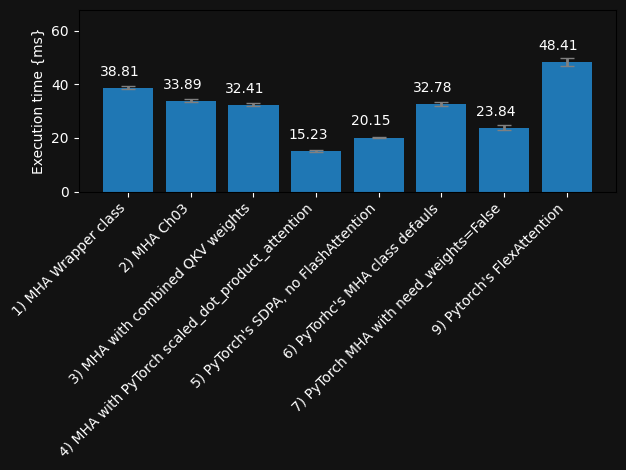

In [ ]:
plot_execution_times(functions, execution_means, execution_stds, filename="1_forward-only.pdf")


## Speed comparison (Nvidia A100 GPU) with warmup (forward and backward pass)

In [ ]:
def forward_backward(func, embeddings):
  if embeddings.grad is not None:
    embeddings.grad.zero()


  output = func(embeddings)
  loss = output.sum()
  loss.backward()

def time_pytorch_function_forward_backward(func, *input, num_repeats = 1_000):
  # CUDA IS AYNCS so can't use python  time module  #
  start = torch.cuda.Event(enable_timing=True)
  end = torch.cuda.Event(enable_timing=True)

  # Warmup
  for _ in range(5):
    forward_backward(func, *input)
  torch.cuda.synchronize()

  times = []

  for _ in range(num_repeats):
    start.record()
    forward_backward(func, *input)
    end.record()
    torch.cuda.synchronize()
    times.append(start.elapsed_time(end))

  return np.mean(times),  np.std(times)


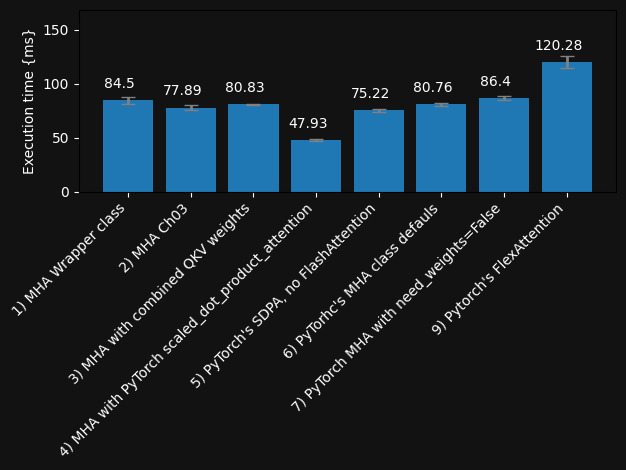

In [ ]:
execution_stats = [time_pytorch_function_forward_backward(fn, embeddings) for fn in functions.values()]
execution_means = [stat[0] for stat in execution_stats]
execution_stds = [stat[1] for stat in execution_stats]


plot_execution_times(functions, execution_means, execution_stds, filename="2_forward-and-backward.pdf")

### Speed comparison (Nvidia A100 GPU) with warmup and compilation (forward and backward pass)

In [ ]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

def prepare_function(fn):
  fn

In [ ]:
execution_stats = [time_pytorch_function_forward_backward(prepare_function(fn), embeddings) for fn in functions.values()]

execution_means = [stat[0] for stat in execution_stats]
execution_means = [stat[0] for stat in execution_stats]


plot_execution_times(functions, execution_means, execution_stds, filename="3_forward-and-backward-compiled.pdf")